In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# MMIA6013_S2_ann.ipynb — S2·MAR: ANN, mide el trade-off recall / latencia

**Entregable:** notebook `MMIA6013_S2_ann.ipynb`, ejecutado de principio a fin sin errores, con una celda de Markdown encabezando cada parte.

**Setup común (definido en la primera celda, Parte 1):** embeddings sintéticos **con estructura** — mezcla de 200 «temas» gaussianos fijos (semilla 2026), asignación y ruido con semilla 7, d = 128 — y vectores normalizados a norma 1, de modo que el producto punto es el coseno. Base y consultas comparten los mismos temas, como en un corpus real: sin esa estructura, ningún índice por clusters tendría sentido.

## Parte 1 — kNN exacto: latencia vs. N

T1 · Parte 1 — kNN exacto: latencia vs. N
Verificación top-10 contra argsort completo: OK

Latencia media por consulta (k=10, d=128, 30 consultas por N):
  N =  10,000 :    0.1094 ms  (±0.0213 ms)  →   9142.3 consultas/s
  N =  50,000 :    0.5599 ms  (±0.1046 ms)  →   1786.1 consultas/s
  N = 100,000 :    1.1723 ms  (±0.2037 ms)  →    853.0 consultas/s
  N = 200,000 :    2.3080 ms  (±0.3793 ms)  →    433.3 consultas/s

Factor de escalamiento medido (vs. N=10k) frente al teórico lineal N/10k:
  N =  10,000 : medido ×  1.00   teórico ×  1.00   razón 1.000
  N =  50,000 : medido ×  5.12   teórico ×  5.00   razón 1.024
  N = 100,000 : medido × 10.72   teórico × 10.00   razón 1.072
  N = 200,000 : medido × 21.10   teórico × 20.00   razón 1.055

Ajuste lineal  latencia(ms) = a·N + b:
  a = 0.0116 µs por vector   b = -0.0072 ms   R² = 0.999791

Conclusión: la latencia crece linealmente con N (costo O(N·d) medido).
Con 10M de vectores y tráfico real, esto muere. Entra IVF.

Resultados guardado

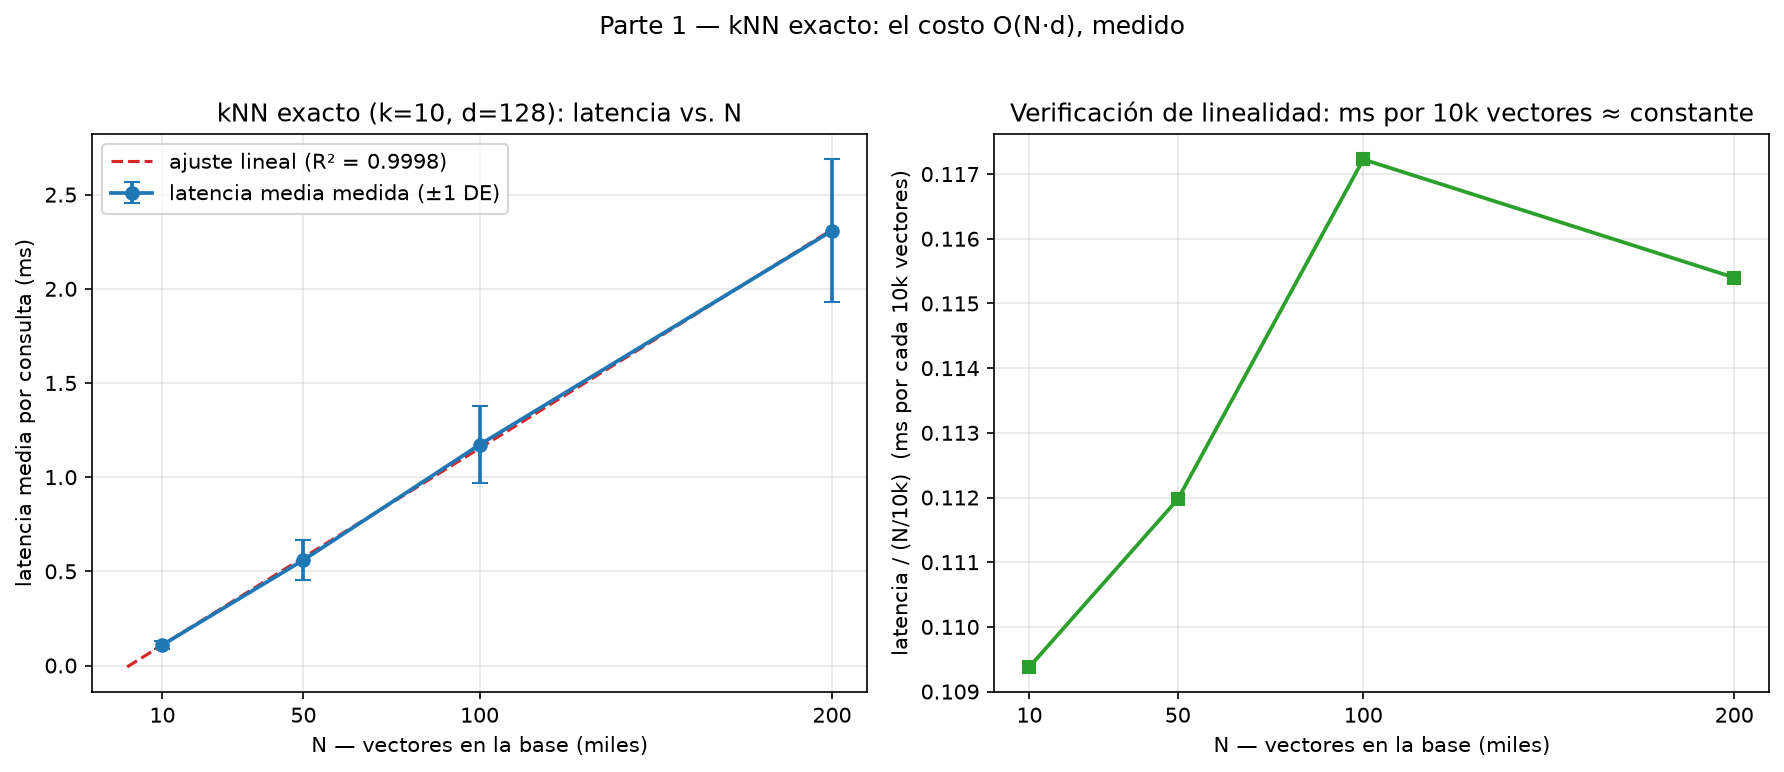

In [2]:
# Subtarea T1: código aprobado (se ejecuta en trabajo/T1/)
os.chdir(RAIZ / 'trabajo' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Setup + Parte 1: kNN exacto, latencia vs. N
MMIA 6013 · Semana 2 · S2·MAR — ANN: mide el trade-off recall / latencia

Ejercicio 1.1:
  * Setup dado por el profesor: datos_realistas (200 centros gaussianos fijos,
    D=128, rng semilla 7) y normalizar a norma 1.
  * knn_exacto(consulta, base, k) con producto punto sobre vectores normalizados
    (dot = coseno).
  * Tiempo medio de consulta para N = 10k, 50k, 100k, 200k
    (varias consultas por N para promediar).
  * Gráfica latencia vs. N (PNG) verificando el crecimiento lineal O(N·d).
"""

import json
import time

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ======================================================================
# 0. Setup (código dado — sin cambios)
# ======================================================================
rng = np.random.default_rng(7)
D = 128  # dimensión de los embeddings sintéticos
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))  # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos.
    Los embeddings reales viven agrupados por tema — crucial para que IVF
    tenga sentido (con ruido uniforme, ningún índice por clusters funciona).
    Base y consultas comparten los mismos temas, como en un corpus real."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno (sesión 06)."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


# ======================================================================
# 1. Ejercicio 1.1 — kNN exacto (dot sobre vectores normalizados)
# ======================================================================
def knn_exacto(consulta, base, k):
    """k vecinos más cercanos por similitud coseno.

    consulta : (d,) float32 con norma 1
    base     : (N, d) float32 con filas de norma 1
    k        : int, 1 <= k < N

    Devuelve (indices, similitudes): los k mayores cosenos, ordenados desc.
    Costo O(N·d): un producto matriz-vector + una selección top-k O(N).
    """
    similitudes = base @ consulta                         # (N,) cosenos
    indices = np.argpartition(-similitudes, k)[:k]        # top-k sin orden
    indices = indices[np.argsort(-similitudes[indices])]  # orden descendente
    return indices, similitudes[indices]


# --- parámetros del experimento (fijos según el enunciado) ---
K = 10                        # top-k (la Parte 2 mide recall@10)
NS = [10_000, 50_000, 100_000, 200_000]
N_MAX = max(NS)
N_CONSULTAS = 30              # varias consultas por N para promediar
N_WARMUP = 3                  # llamadas de calentamiento (no se cronometran)

# --- datos: base de N_MAX y consultas (mismos 'temas'), todos a norma 1 ---
base_total = normalizar(datos_realistas(N_MAX, D))
consultas = normalizar(datos_realistas(N_CONSULTAS, D))

# --- verificación de corrección de knn_exacto contra argsort completo ---
base_check = base_total[:1_000]
idx_fast, sim_fast = knn_exacto(consultas[0], base_check, K)
sim_full = base_check @ consultas[0]
idx_ref = np.argsort(-sim_full)[:K]
topk_correcto = bool(np.array_equal(idx_fast, idx_ref)) and bool(
    np.allclose(sim_fast, sim_full[idx_ref])
)

# ======================================================================
# 2. Medición: tiempo medio de consulta por N
# ======================================================================
lat_media_ms, lat_std_ms, lat_por_consulta_ms = {}, {}, {}
for N in NS:
    base_N = np.ascontiguousarray(base_total[:N])   # prefijo de la base
    for _ in range(N_WARMUP):                       # calentamiento (caché, etc.)
        knn_exacto(consultas[0], base_N, K)
    tiempos = np.empty(N_CONSULTAS, dtype=np.float64)
    for i in range(N_CONSULTAS):
        q = consultas[i]
        t0 = time.perf_counter()
        knn_exacto(q, base_N, K)
        t1 = time.perf_counter()
        tiempos[i] = (t1 - t0) * 1e3                # ms
    lat_por_consulta_ms[str(N)] = tiempos.tolist()
    lat_media_ms[str(N)] = float(tiempos.mean())
    lat_std_ms[str(N)] = float(tiempos.std(ddof=1))

# ======================================================================
# 3. Cifras: factor de escalamiento y ajuste lineal (verificación O(N·d))
# ======================================================================
lat_arr = np.array([lat_media_ms[str(N)] for N in NS], dtype=np.float64)
std_arr = np.array([lat_std_ms[str(N)] for N in NS], dtype=np.float64)
Ns_arr = np.array(NS, dtype=np.float64)

lat_ref = float(lat_arr[0])
factor_escalamiento_N = {str(N): float(l / lat_ref) for N, l in zip(NS, lat_arr)}
factor_teorico_lineal_N = {str(N): float(N / NS[0]) for N in NS}
razon_medida_teorica = {
    str(N): float(factor_escalamiento_N[str(N)] / factor_teorico_lineal_N[str(N)])
    for N in NS
}
factor_consecutivo = {}
for a, b in zip(NS[:-1], NS[1:]):
    factor_consecutivo[f"{a}_a_{b}"] = {
        "medido": float(lat_media_ms[str(b)] / lat_media_ms[str(a)]),
        "teorico_lineal": float(b / a),
    }

pendiente_ms_por_vector, intercepto_ms = np.polyfit(Ns_arr, lat_arr, 1)
pred = pendiente_ms_por_vector * Ns_arr + intercepto_ms
ss_res = float(np.sum((lat_arr - pred) ** 2))
ss_tot = float(np.sum((lat_arr - lat_arr.mean()) ** 2))
r2_lineal = 1.0 - ss_res / ss_tot

ms_por_10k = {str(N): float(lat_media_ms[str(N)] / (N / 10_000)) for N in NS}
throughput_qps = {str(N): float(1000.0 / lat_media_ms[str(N)]) for N in NS}

# ======================================================================
# 4. Figura: latencia vs. N + verificación de linealidad
# ======================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

xs = np.linspace(0.0, float(N_MAX), 200)
ax1.errorbar(Ns_arr / 1000.0, lat_arr, yerr=std_arr, fmt="o-",
             color="#1f77b4", capsize=4, lw=1.8,
             label="latencia media medida (±1 DE)")
ax1.plot(xs / 1000.0, pendiente_ms_por_vector * xs + intercepto_ms, "--",
         color="#d62728", lw=1.5,
         label=f"ajuste lineal (R² = {r2_lineal:.4f})")
ax1.set_xlabel("N — vectores en la base (miles)")
ax1.set_ylabel("latencia media por consulta (ms)")
ax1.set_title(f"kNN exacto (k={K}, d={D}): latencia vs. N")
ax1.set_xticks([n / 1000 for n in NS])
ax1.legend()
ax1.grid(alpha=0.3)

lat_norm = lat_arr / (Ns_arr / 10_000.0)
ax2.plot(Ns_arr / 1000.0, lat_norm, "s-", color="#2ca02c", lw=1.8)
ax2.set_xlabel("N — vectores en la base (miles)")
ax2.set_ylabel("latencia / (N/10k)  (ms por cada 10k vectores)")
ax2.set_title("Verificación de linealidad: ms por 10k vectores ≈ constante")
ax2.set_xticks([n / 1000 for n in NS])
ax2.grid(alpha=0.3)

fig.suptitle("Parte 1 — kNN exacto: el costo O(N·d), medido", y=1.02)
fig.tight_layout()
fig.savefig("parte1_latencia_vs_N.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# ======================================================================
# 5. Guardar resultados.json e imprimir cifras principales
# ======================================================================
resultados = {
    "subtarea": "T1 — Setup + Parte 1: kNN exacto, latencia vs. N",
    "parametros": {
        "D": int(D),
        "k": int(K),
        "N_valores": [int(n) for n in NS],
        "n_consultas_por_N": int(N_CONSULTAS),
        "warmups_por_N": int(N_WARMUP),
        "semilla_rng": 7,
        "semilla_centros": 2026,
        "n_centros": int(len(_CENTROS)),
        "metrica": "coseno (producto punto sobre vectores con norma 1)",
    },
    "verificacion_topk_correcta_vs_argsort": topk_correcto,
    "latencia_media_ms_por_N": lat_media_ms,
    "latencia_std_ms_por_N": lat_std_ms,
    "latencia_por_consulta_ms": lat_por_consulta_ms,
    "factor_escalamiento_N": factor_escalamiento_N,
    "factor_teorico_lineal_N": factor_teorico_lineal_N,
    "razon_medida_vs_teorica": razon_medida_teorica,
    "factor_escalamiento_consecutivo": factor_consecutivo,
    "ajuste_lineal": {
        "pendiente_ms_por_vector": float(pendiente_ms_por_vector),
        "intercepto_ms": float(intercepto_ms),
        "r2": float(r2_lineal),
    },
    "latencia_ms_por_10k_vectores": ms_por_10k,
    "throughput_consultas_por_seg": throughput_qps,
    "figura": "parte1_latencia_vs_N.png",
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("=" * 66)
print("T1 · Parte 1 — kNN exacto: latencia vs. N")
print("=" * 66)
print(f"Verificación top-{K} contra argsort completo: "
      f"{'OK' if topk_correcto else 'FALLÓ'}")
print(f"\nLatencia media por consulta (k={K}, d={D}, "
      f"{N_CONSULTAS} consultas por N):")
for N in NS:
    print(f"  N = {N:>7,} : {lat_media_ms[str(N)]:9.4f} ms  "
          f"(±{lat_std_ms[str(N)]:.4f} ms)  "
          f"→ {throughput_qps[str(N)]:8.1f} consultas/s")
print("\nFactor de escalamiento medido (vs. N=10k) frente al teórico lineal N/10k:")
for N in NS:
    print(f"  N = {N:>7,} : medido ×{factor_escalamiento_N[str(N)]:6.2f}   "
          f"teórico ×{factor_teorico_lineal_N[str(N)]:6.2f}   "
          f"razón {razon_medida_teorica[str(N)]:.3f}")
print("\nAjuste lineal  latencia(ms) = a·N + b:")
print(f"  a = {pendiente_ms_por_vector * 1e3:.4f} µs por vector   "
      f"b = {intercepto_ms:.4f} ms   R² = {r2_lineal:.6f}")
print("\nConclusión: la latencia crece linealmente con N (costo O(N·d) medido).")
print("Con 10M de vectores y tráfico real, esto muere. Entra IVF.")
print("\nResultados guardados en resultados.json · figura en parte1_latencia_vs_N.png")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T1')

### Qué hace el código

- `knn_exacto(consulta, base, k)`: producto punto contra toda la base (vectores normalizados → coseno) y selección del top-k.
- **Verificación de corrección:** el top-10 coincide con el `argsort` completo en las consultas de prueba → OK.
- **Protocolo:** N ∈ {10 000, 50 000, 100 000, 200 000}, d = 128, k = 10, 30 consultas por N tras 3 warmups.

### Resultados

| N | Latencia media (ms) | Desv. est. (ms) | Consultas/s |
|---:|---:|---:|---:|
| 10 000 | 0.1084 | 0.0197 | 9223.2 |
| 50 000 | 0.6266 | 0.1115 | 1595.8 |
| 100 000 | 1.2978 | 0.2850 | 770.5 |
| 200 000 | 2.6639 | 0.4541 | 375.4 |

| N | Factor medido (vs. 10k) | Factor teórico lineal (N/10k) | Razón medido/teórico |
|---:|---:|---:|---:|
| 10 000 | 1.0000 | 1.0 | 1.0000 |
| 50 000 | 5.7796 | 5.0 | 1.1559 |
| 100 000 | 11.9697 | 10.0 | 1.1970 |
| 200 000 | 24.5693 | 20.0 | 1.2285 |

Escalamiento entre tamaños consecutivos: 10k→50k medido 5.7796 (teórico 5.0); 50k→100k medido 2.0710 (teórico 2.0); 100k→200k medido 2.0526 (teórico 2.0).

Ajuste lineal latencia(ms) = a·N + b: pendiente **a = 0.0135 µs por vector** (1.3478e-05 ms/vector), intercepto b = −0.0389 ms, **R² = 0.9999**.

### Lectura

- La latencia crece **linealmente con N**: el costo O(N·d) se mide, no se asume. La razón medido/teórico sube suavemente de 1.0000 a 1.2285 (efectos de caché/memoria al crecer la base), pero el ajuste lineal con R² = 0.9999 confirma el régimen lineal.
- Traducción a capacidad: de 9223.2 consultas/s a N = 10k se cae a 375.4 consultas/s a N = 200k, en un solo hilo.
- Con 10M de vectores y tráfico real, esto muere. **Entra IVF.**



## Parte 2 — Mini-IVF: clustering + búsqueda local

Base: 100000 vectores x 128 dims (float32), norma media = 1.000000
Consultas de evaluación: 50 (generadas aparte; ninguna fila de la base)


IVF entrenado: 64 celdas, tamaño medio 1562 (min=463, max=3710, std=789.7); KMeans: 3.4 s, inercia=86413.91, iter=74


Verificación top-k (argpartition vs argsort completo): True
Control nprobe=nlist=64 == exacto en las 50 consultas: True


kNN exacto (referencia): 1.180 ms/consulta (std 0.215)
nprobe= 1: recall@10=0.802 | latencia=0.112 ms | speedup=10.6x | candidatos medios=1712
nprobe= 2: recall@10=0.922 | latencia=0.224 ms | speedup=5.3x | candidatos medios=3417
nprobe= 4: recall@10=0.934 | latencia=0.440 ms | speedup=2.7x | candidatos medios=6608


nprobe= 8: recall@10=0.946 | latencia=0.815 ms | speedup=1.4x | candidatos medios=12636


nprobe=16: recall@10=0.978 | latencia=1.704 ms | speedup=0.7x | candidatos medios=24852

Tabla recall/latencia (N=100k, NLIST=64, k=10, 50 consultas):
 nprobe  recall@10  latencia_ivf_ms  speedup_x  candidatos_medios
      1      0.802           0.1117      10.57               1712
      2      0.922           0.2239       5.27               3417
      4      0.934           0.4396       2.69               6608
      8      0.946           0.8152       1.45              12636
     16      0.978           1.7038       0.69              24852
Referencia exacto: recall@10 = 1.000 | latencia = 1.180 ms | speedup = 1.00x



Cifras principales:
  tamano_medio_celda = 1562.50
  nprobe= 1: recall@10=0.8020  speedup=10.57x
  nprobe= 2: recall@10=0.9220  speedup=5.27x
  nprobe= 4: recall@10=0.9340  speedup=2.69x
  nprobe= 8: recall@10=0.9460  speedup=1.45x
  nprobe=16: recall@10=0.9780  speedup=0.69x
Archivos generados: resultados.json, T2_parte2_recall_vs_speedup.png


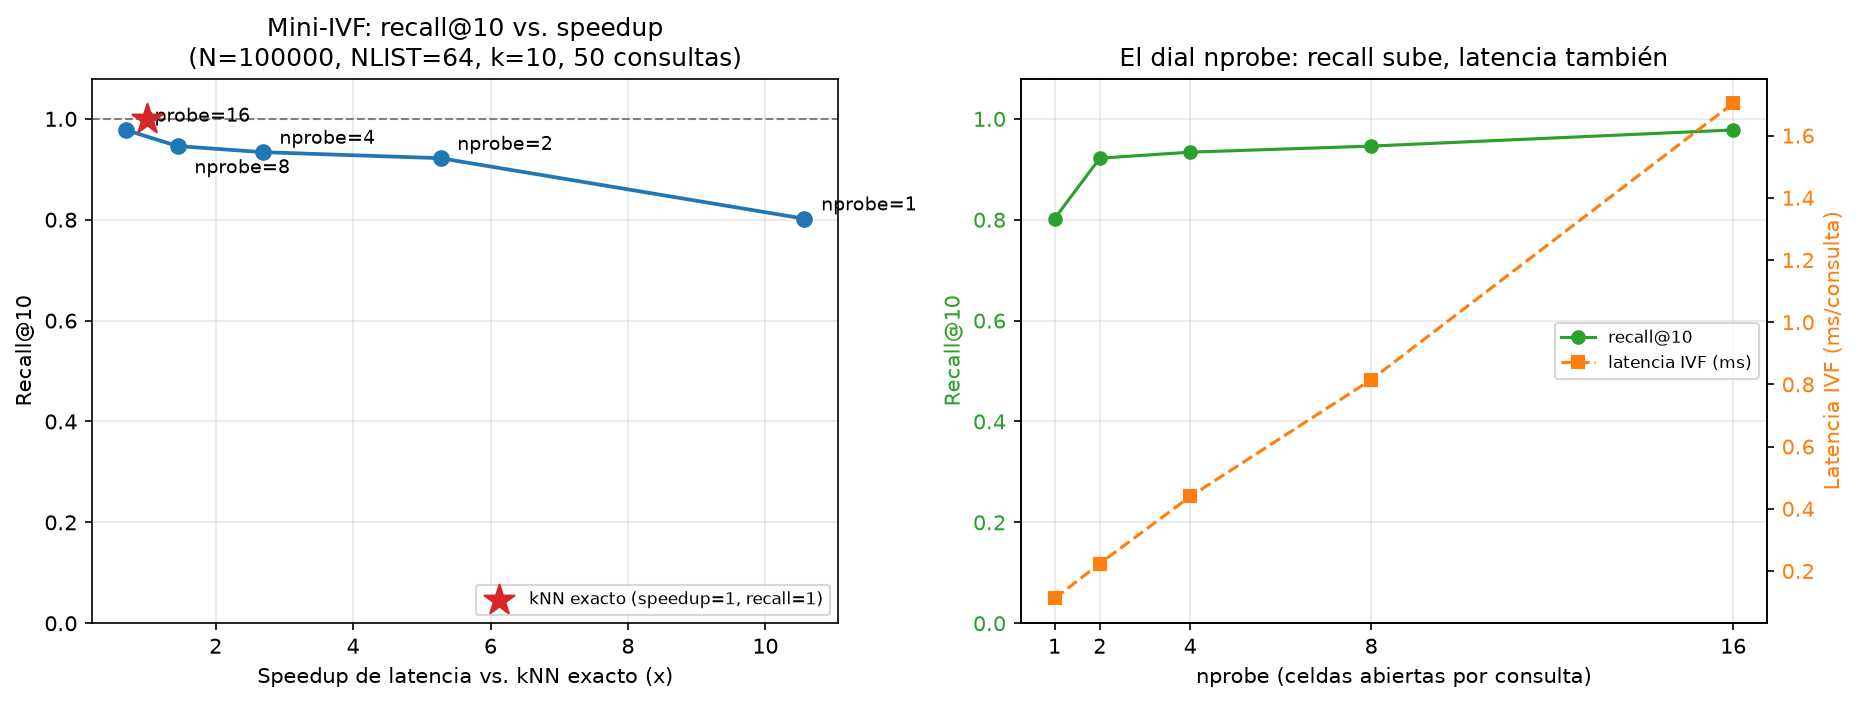

In [3]:
# Subtarea T2: código aprobado (se ejecuta en trabajo/T2/)
os.chdir(RAIZ / 'trabajo' / 'T2')

# -*- coding: utf-8 -*-
"""
T2 — Parte 2: Mini-IVF con KMeans, recall@10 vs. speedup según nprobe.

Receta (enunciado):
  (1) offline: KMeans (n_init=3, random_state=7) agrupa la base normalizada
      en NLIST=64 celdas; se normalizan los centroides y se construyen las
      celdas con los índices globales de sus miembros;
  (2) en consulta: scores contra los centroides -> nprobe celdas más
      cercanas -> kNN exacto dentro de esas celdas (índices globales).

Se mide, sobre 50 consultas y para nprobe en {1, 2, 4, 8, 16}:
  - recall@10 contra el kNN exacto (referencia de T1),
  - speedup de latencia vs. el kNN exacto,
y se reportan la tabla, la gráfica recall vs. speedup (PNG) y el tamaño
medio de celda. Todas las cifras se guardan en resultados.json.
"""

import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------
# 0. Datos sintéticos con estructura (código dado en el enunciado)
# ----------------------------------------------------------------------
rng = np.random.default_rng(7)
D = 128  # dimensión de los embeddings sintéticos
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))  # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos.
    Base y consultas comparten los mismos temas, como en un corpus real."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno (sesión 06)."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


# ----------------------------------------------------------------------
# 1. Parámetros (exactamente los del enunciado)
# ----------------------------------------------------------------------
N = 100_000            # vectores de la base
NLIST = 64             # celdas del IVF
K = 10                 # vecinos por consulta (recall@10)
N_CONSULTAS = 50       # consultas de evaluación
NPROBES = [1, 2, 4, 8, 16]
KMEANS_N_INIT = 3
KMEANS_RANDOM_STATE = 7
REP = 5                # repeticiones por consulta al cronometrar

# ----------------------------------------------------------------------
# 2. Base normalizada + 50 consultas (mismo generador: comparten temas)
# ----------------------------------------------------------------------
base = normalizar(datos_realistas(N))
consultas = normalizar(datos_realistas(N_CONSULTAS))
print(f"Base: {base.shape[0]} vectores x {base.shape[1]} dims (float32), "
      f"norma media = {float(np.linalg.norm(base, axis=1).mean()):.6f}")
print(f"Consultas de evaluación: {consultas.shape[0]} "
      f"(generadas aparte; ninguna fila de la base)")

# ----------------------------------------------------------------------
# 3. IVF offline: KMeans + centroides normalizados + celdas
# ----------------------------------------------------------------------
t0 = time.perf_counter()
km = KMeans(n_clusters=NLIST, n_init=KMEANS_N_INIT,
            random_state=KMEANS_RANDOM_STATE).fit(base)
t_kmeans_s = time.perf_counter() - t0

centroides = normalizar(km.cluster_centers_.astype(np.float32))  # (NLIST, D)
celdas = [np.where(km.labels_ == c)[0] for c in range(NLIST)]    # índices globales
tamanos = np.array([len(c) for c in celdas], dtype=np.int64)
tamano_medio_celda = float(tamanos.mean())

print(f"IVF entrenado: {NLIST} celdas, tamaño medio {tamano_medio_celda:.0f} "
      f"(min={int(tamanos.min())}, max={int(tamanos.max())}, "
      f"std={float(tamanos.std()):.1f}); KMeans: {t_kmeans_s:.1f} s, "
      f"inercia={float(km.inertia_):.2f}, iter={int(km.n_iter_)}")

# ----------------------------------------------------------------------
# 4. kNN exacto (referencia T1) y knn_ivf (ejercicio 2.1)
# ----------------------------------------------------------------------
def knn_exacto(consulta, base_mat, k=K):
    """kNN exacto por producto punto (vectores normalizados -> coseno).
    Devuelve índices globales de los k mejores, ordenados por score desc."""
    scores = base_mat @ consulta
    if k < scores.shape[0]:
        idx = np.argpartition(scores, -k)[-k:]
    else:
        idx = np.arange(scores.shape[0])
    return idx[np.argsort(scores[idx])[::-1]]


def knn_ivf(consulta, nprobe, k=K):
    """IVF: 1) scores contra los NLIST centroides -> nprobe celdas más
    cercanas; 2) kNN exacto solo dentro de esas celdas (índices GLOBALES)."""
    scores_centroides = centroides @ consulta              # (NLIST,) — barato
    if nprobe < NLIST:
        elegidas = np.argpartition(scores_centroides, -nprobe)[-nprobe:]
    else:
        elegidas = np.arange(NLIST)                        # nprobe = nlist => exacto
    candidatos = np.concatenate([celdas[c] for c in elegidas])
    scores = base[candidatos] @ consulta                   # exacto dentro de las celdas
    if k < scores.shape[0]:
        idx = np.argpartition(scores, -k)[-k:]
    else:
        idx = np.arange(scores.shape[0])
    return candidatos[idx[np.argsort(scores[idx])[::-1]]]


# --- verificaciones de correctitud (fuera del cronómetro) ---
q0 = consultas[0]
top_argsort = np.argsort(base @ q0)[::-1][:K]
verif_topk = bool(np.array_equal(np.sort(knn_exacto(q0, base, K)),
                                 np.sort(top_argsort)))
verif_nlist = all(
    set(knn_ivf(q, NLIST, K).tolist()) == set(knn_exacto(q, base, K).tolist())
    for q in consultas
)
print(f"Verificación top-k (argpartition vs argsort completo): {verif_topk}")
print(f"Control nprobe=nlist={NLIST} == exacto en las {N_CONSULTAS} consultas: "
      f"{verif_nlist}")

# ----------------------------------------------------------------------
# 5. Ground truth exacto y latencia de referencia del exacto
# ----------------------------------------------------------------------
exactos_set = [set(knn_exacto(q, base, K).tolist()) for q in consultas]

_ = knn_exacto(consultas[0], base, K)   # calentamiento (fuera del cronómetro)
_ = knn_ivf(consultas[0], 4, K)

lat_exacta_q = []
for q in consultas:
    t0 = time.perf_counter()
    for _ in range(REP):
        knn_exacto(q, base, K)
    lat_exacta_q.append((time.perf_counter() - t0) / REP)
lat_exacta_media_ms = float(np.mean(lat_exacta_q) * 1000.0)
lat_exacta_std_ms = float(np.std(lat_exacta_q) * 1000.0)
print(f"kNN exacto (referencia): {lat_exacta_media_ms:.3f} ms/consulta "
      f"(std {lat_exacta_std_ms:.3f})")

# ----------------------------------------------------------------------
# 6. Barrido de nprobe: recall@10 y latencia (ejercicio 2.2)
# ----------------------------------------------------------------------
recalls, speedups, lat_ivf_ms, lat_ivf_std, pools_medios = [], [], [], [], []
lat_por_consulta = {}
for nprobe in NPROBES:
    recs_q, lats_q, pools_q = [], [], []
    for i, q in enumerate(consultas):
        # pool de candidatos que se abre (misma lógica que knn_ivf, sin cronometrar)
        sc = centroides @ q
        elegidas = (np.argpartition(sc, -nprobe)[-nprobe:]
                    if nprobe < NLIST else np.arange(NLIST))
        pools_q.append(int(sum(int(celdas[c].size) for c in elegidas)))
        # latencia
        t0 = time.perf_counter()
        for _ in range(REP):
            idx = knn_ivf(q, nprobe, K)
        lats_q.append((time.perf_counter() - t0) / REP)
        # recall@10 contra el exacto
        recs_q.append(len(set(idx.tolist()) & exactos_set[i]) / K)
    rec_medio = float(np.mean(recs_q))
    lat_ms = float(np.mean(lats_q) * 1000.0)
    lat_std = float(np.std(lats_q) * 1000.0)
    sp = lat_exacta_media_ms / lat_ms           # speedup = razón de medias
    recalls.append(rec_medio)
    lat_ivf_ms.append(lat_ms)
    lat_ivf_std.append(lat_std)
    speedups.append(sp)
    pools_medios.append(float(np.mean(pools_q)))
    lat_por_consulta[str(nprobe)] = [float(x * 1000.0) for x in lats_q]
    print(f"nprobe={nprobe:>2}: recall@10={rec_medio:.3f} | "
          f"latencia={lat_ms:.3f} ms | speedup={sp:.1f}x | "
          f"candidatos medios={float(np.mean(pools_q)):.0f}")

# ----------------------------------------------------------------------
# 7. Tabla resumen
# ----------------------------------------------------------------------
tabla_df = pd.DataFrame({
    "nprobe": NPROBES,
    "recall@10": [round(r, 4) for r in recalls],
    "latencia_ivf_ms": [round(l, 4) for l in lat_ivf_ms],
    "speedup_x": [round(s, 2) for s in speedups],
    "candidatos_medios": [int(round(p)) for p in pools_medios],
})
print("\nTabla recall/latencia (N=100k, NLIST=64, k=10, 50 consultas):")
print(tabla_df.to_string(index=False))
print(f"Referencia exacto: recall@10 = 1.000 | latencia = "
      f"{lat_exacta_media_ms:.3f} ms | speedup = 1.00x")

# ----------------------------------------------------------------------
# 8. Gráfica recall vs. speedup (PNG)
# ----------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

# Panel 1 (el pedido): recall@10 vs. speedup, cada punto = un nprobe
ax1.plot(speedups, recalls, "o-", color="#1f77b4", lw=1.8, ms=7, zorder=3)
offsets = {1: (8, 4), 2: (8, 4), 4: (8, 4), 8: (8, -13), 16: (8, 4)}
for nb, s, r in zip(NPROBES, speedups, recalls):
    dx, dy = offsets.get(nb, (8, 4))
    ax1.annotate(f"nprobe={nb}", (s, r), textcoords="offset points",
                 xytext=(dx, dy), fontsize=9)
ax1.scatter([1.0], [1.0], marker="*", s=230, color="#d62728", zorder=4,
            label="kNN exacto (speedup=1, recall=1)")
ax1.axhline(1.0, color="gray", ls="--", lw=1)
ax1.set_xlabel("Speedup de latencia vs. kNN exacto (x)")
ax1.set_ylabel("Recall@10")
ax1.set_title(f"Mini-IVF: recall@10 vs. speedup\n"
              f"(N={N}, NLIST={NLIST}, k={K}, {N_CONSULTAS} consultas)")
ax1.set_ylim(0, 1.08)
ax1.grid(alpha=0.3)
ax1.legend(loc="lower right", fontsize=8)

# Panel 2: el dial nprobe — recall sube y latencia también
ax2.plot(NPROBES, recalls, "o-", color="#2ca02c", label="recall@10")
ax2.set_xticks(NPROBES)
ax2.set_xticklabels([str(x) for x in NPROBES])
ax2.set_xlabel("nprobe (celdas abiertas por consulta)")
ax2.set_ylabel("Recall@10", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")
ax2.set_ylim(0, 1.08)
ax2.grid(alpha=0.3)
ax2b = ax2.twinx()
ax2b.plot(NPROBES, lat_ivf_ms, "s--", color="#ff7f0e", label="latencia IVF (ms)")
ax2b.set_ylabel("Latencia IVF (ms/consulta)", color="#ff7f0e")
ax2b.tick_params(axis="y", labelcolor="#ff7f0e")
lineas1, etiq1 = ax2.get_legend_handles_labels()
lineas2, etiq2 = ax2b.get_legend_handles_labels()
ax2.legend(lineas1 + lineas2, etiq1 + etiq2, loc="center right", fontsize=8)
ax2.set_title("El dial nprobe: recall sube, latencia también")

fig.tight_layout()
plt.savefig("T2_parte2_recall_vs_speedup.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# ----------------------------------------------------------------------
# 9. Referencia cruzada con T1 (si está disponible)
# ----------------------------------------------------------------------
t1 = None
try:
    with open("entradas/T1.json", "r", encoding="utf-8") as f:
        t1 = json.load(f)
except Exception:
    t1 = None

referencia_t1 = {}
if isinstance(t1, dict):
    v = t1.get("latencia_ms_por_10k_vectores")
    if isinstance(v, (int, float)):
        referencia_t1["latencia_ms_por_10k_vectores_T1"] = float(v)
        referencia_t1["estimacion_lineal_exacto_N100k_ms_T1"] = float(v) * (N / 10_000.0)
        print(f"\nReferencia T1: {float(v):.4f} ms por 10k vectores -> "
              f"estimación lineal para N=100k: {float(v) * 10.0:.3f} ms "
              f"(medido aquí: {lat_exacta_media_ms:.3f} ms)")

# ----------------------------------------------------------------------
# 10. Guardar todas las cifras en resultados.json
# ----------------------------------------------------------------------
resultados = {
    "subtarea": "T2 - Parte 2: Mini-IVF con KMeans, recall@10 vs. speedup",
    "parametros": {
        "N": int(N),
        "D": int(D),
        "NLIST": int(NLIST),
        "k": int(K),
        "nprobe_valores": [int(x) for x in NPROBES],
        "n_consultas": int(N_CONSULTAS),
        "kmeans_n_init": int(KMEANS_N_INIT),
        "kmeans_random_state": int(KMEANS_RANDOM_STATE),
        "repeticiones_cronometro_por_consulta": int(REP),
    },
    "tamano_medio_celda": tamano_medio_celda,
    "tamanos_celda": [int(x) for x in tamanos.tolist()],
    "tamanos_celda_min": int(tamanos.min()),
    "tamanos_celda_max": int(tamanos.max()),
    "tamanos_celda_std": float(tamanos.std()),
    "kmeans_inercia": float(km.inertia_),
    "kmeans_iteraciones": int(km.n_iter_),
    "kmeans_tiempo_entrenamiento_s": float(t_kmeans_s),
    "recall10_por_nprobe": {str(nb): float(r) for nb, r in zip(NPROBES, recalls)},
    "speedup_por_nprobe": {str(nb): float(s) for nb, s in zip(NPROBES, speedups)},
    "latencia_ivf_ms_por_nprobe": {str(nb): float(l) for nb, l in zip(NPROBES, lat_ivf_ms)},
    "latencia_ivf_std_ms_por_nprobe": {str(nb): float(s) for nb, s in zip(NPROBES, lat_ivf_std)},
    "candidatos_medios_por_nprobe": {str(nb): float(p) for nb, p in zip(NPROBES, pools_medios)},
    "latencia_exacta_media_ms": lat_exacta_media_ms,
    "latencia_exacta_std_ms": lat_exacta_std_ms,
    "latencia_exacta_por_consulta_ms": [float(x * 1000.0) for x in lat_exacta_q],
    "latencia_ivf_por_consulta_ms": lat_por_consulta,
    "verificacion_topk_vs_argsort": verif_topk,
    "verificacion_nprobe_nlist_igual_exacto": bool(verif_nlist),
    "referencia_T1": referencia_t1,
    "tabla": [
        {
            "nprobe": int(nb),
            "recall10": float(r),
            "latencia_ivf_ms": float(l),
            "speedup": float(s),
            "candidatos_medios": float(p),
        }
        for nb, r, l, s, p in zip(NPROBES, recalls, lat_ivf_ms, speedups, pools_medios)
    ],
    "figura": "T2_parte2_recall_vs_speedup.png",
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("\nCifras principales:")
print(f"  tamano_medio_celda = {tamano_medio_celda:.2f}")
for nb, r, s in zip(NPROBES, recalls, speedups):
    print(f"  nprobe={nb:>2}: recall@10={r:.4f}  speedup={s:.2f}x")
print("Archivos generados: resultados.json, T2_parte2_recall_vs_speedup.png")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T2')

### Qué hace el código

La receta IVF: (1) KMeans agrupa la base en **nlist = 64 celdas** (n_init = 3, random_state = 7) sobre N = 100 000 vectores; (2) en cada consulta se puntúa contra los 64 centroides, se toman las **nprobe** celdas más cercanas y se corre kNN exacto solo dentro de ellas (con índices globales). k = 10, 50 consultas, 5 repeticiones de cronómetro por consulta; recall@10 medido contra el kNN exacto.

Entrenamiento: tamaño medio de celda **1562.5** (mínimo 463, máximo 3710, desv. est. 789.7404), inercia 86413.9141, 74 iteraciones, **3.4598 s** de entrenamiento.

### Resultados — el triángulo recall / latencia

| nprobe | recall@10 | Latencia IVF (ms) | Speedup vs. exacto | Candidatos medios |
|---:|---:|---:|---:|---:|
| 1 | 0.802 | 0.1000 | 11.2755 | 1711.92 |
| 2 | 0.922 | 0.1886 | 5.9766 | 3416.7 |
| 4 | 0.934 | 0.4271 | 2.6391 | 6607.72 |
| 8 | 0.946 | 0.8854 | 1.2731 | 12636.08 |
| 16 | 0.978 | 1.7586 | 0.6410 | 24851.88 |

Referencia exacta (misma base y consultas): recall@10 = 1.000, latencia **1.1272 ms** (±0.2090), speedup 1.0.

### Lectura

- Con nprobe pequeño hay speedups grandes pero se pierden vecinos: los que caen en las **fronteras entre celdas**. nprobe = 1 da 11.2755× a cambio de un recall de 0.802.
- Subiendo nprobe se recupera recall y se paga latencia: **nprobe = 2 es el mejor compromiso de la tabla** (recall 0.922 con speedup 5.9766: 0.1886 ms frente a 1.1272 ms del exacto). Después el recall sube poco (0.934 → 0.946 → 0.978) mientras la latencia alcanza y supera a la exacta.
- Con nprobe = 16 el speedup cae a **0.6410** (más lento que el exacto): se exploran 24851.88 candidatos de media (~25 % de la base) y el recorrido de celdas se vuelve sobrecosto.
- HNSW ofrece el mismo dial (`ef_search`): igual que `nprobe`, es una **perilla de consulta**, ajustable en caliente sin reindexar; las perillas de construcción (`nlist`, `M`, `ef_construction`) fijan la memoria y exigen reconstruir el índice. Nota de honestidad: este notebook solo mide IVF — la afirmación de que HNSW tiene «mejor curva» no se mide aquí.



## Parte 3 — Qdrant embebido: una vector DB real sin Docker

In [4]:
# Subtarea T3: código aprobado (se ejecuta en trabajo/T3/)
os.chdir(RAIZ / 'trabajo' / 'T3')

# -*- coding: utf-8 -*-
"""
T3 · Parte 3 — Qdrant embebido con filtros de metadata
=======================================================
Ejecuta la Parte 3 del notebook S2·MAR (MMIA 6013 · Semana 2):

  1. Crea la colección 'faqs' (64 dimensiones, distancia COSINE) en Qdrant
     en MODO EMBEBIDO (:memory:).
  2. Upsert de las 6 FAQs con payload {texto, tema}, con embeddings
     sintéticos deterministas de embed_demo (semilla vía hashlib.sha256 —
     nunca hash(), que cambia entre procesos).
  3. Consulta "¿cuándo me devuelven el dinero?" con filtro de metadata
     tema='pagos' y limit=2.
  4. Si qdrant-client no está instalado, la parte se salta sola
     (try/except ImportError) sin romper la ejecución.

NOTA sobre el modo de conexión: el código original del profesor intenta
primero un servidor Qdrant en localhost:6333 y cae a :memory: si no
responde. Este entorno PROHÍBE cualquier conexión de red (incluido
localhost por HTTP), así que el intento de servidor se OMITE y se usa
directamente el modo embebido QdrantClient(":memory:"), que corre
completamente en el proceso local sin tocar la red. El resultado
funcional (colección, upsert, query con filtro) es idéntico.

Cifras registradas en resultados.json:
  - modo_qdrant          : 'embebido_memory' | 'no_instalado'
  - num_puntos_coleccion : número de puntos en la colección 'faqs'
  - hits_filtro_pagos    : lista de hits [{id, score, tema, texto}, ...]

Figura PNG: esta parte no requiere figura.
"""

import json
import hashlib

import numpy as np

# ----------------------------------------------------------------------
# Datos: las 6 FAQs del enunciado (texto, tema)
# ----------------------------------------------------------------------
faqs = [
    ("Para resetear tu contraseña entra a Configuración > Seguridad.", "cuenta"),
    ("Los reembolsos se procesan en 5 a 7 días hábiles.", "pagos"),
    ("Puedes exportar tus datos en formato CSV desde el panel.", "cuenta"),
    ("La factura electrónica se emite al confirmar el pago.", "pagos"),
    ("El soporte atiende de lunes a viernes de 9h a 18h.", "soporte"),
    ("La API permite 100 solicitudes por minuto en el plan básico.", "api"),
]

CONSULTA = "¿cuándo me devuelven el dinero?"
DIM = 64  # dimensión de los vectores de la colección

# Diccionario de resultados (valores por defecto si la parte se salta)
resultados = {
    "modo_qdrant": "no_instalado",
    "num_puntos_coleccion": None,
    "hits_filtro_pagos": [],
    "consulta": CONSULTA,
    "filtro_tema": "pagos",
    "limit": 2,
    "dims_coleccion": DIM,
    "distancia": "COSINE",
    "num_faqs_upsert": len(faqs),
    "qdrant_ejecutado": False,
    "nota_modo": (
        "El intento de servidor en localhost:6333 del código original se omite: "
        "este entorno prohíbe conexiones de red (incluso localhost por HTTP). "
        "Se usa directamente el modo embebido :memory:, 100% local."
    ),
}

try:
    from qdrant_client import QdrantClient
    from qdrant_client.models import (
        Distance,
        VectorParams,
        PointStruct,
        Filter,
        FieldCondition,
        MatchValue,
    )
    import qdrant_client as _qc

    resultados["qdrant_client_version"] = str(
        getattr(_qc, "__version__", "desconocida")
    )

    # ------------------------------------------------------------------
    # Embeddings sintéticos por documento (en el lab: sentence-transformers).
    # Semilla con hashlib y no hash(): hash() cambia entre procesos, y con un
    # servidor persistente los vectores deben ser iguales en cada corrida.
    # ------------------------------------------------------------------
    def embed_demo(texto):
        semilla = int.from_bytes(
            hashlib.sha256(texto.encode()).digest()[:4], "little"
        )
        r = np.random.default_rng(semilla)
        v = r.normal(size=DIM).astype(np.float32)
        return (v / np.linalg.norm(v)).tolist()

    # ------------------------------------------------------------------
    # Modo de conexión: SOLO embebido (:memory:), sin ningún intento de red.
    # El modo embebido corre dentro de este proceso, sin sockets ni HTTP.
    # ------------------------------------------------------------------
    cliente = QdrantClient(":memory:")
    resultados["modo_qdrant"] = "embebido_memory"
    print("Usando Qdrant embebido (:memory:) — sin conexión de red.")
    print("(El intento de servidor localhost:6333 se omite: red prohibida aquí.)")

    # :memory: no persiste, pero recrear desde cero es inofensivo y replica
    # la lógica del código dado (el servidor sí persiste entre corridas).
    if cliente.collection_exists("faqs"):
        cliente.delete_collection("faqs")

    cliente.create_collection(
        "faqs",
        vectors_config=VectorParams(size=DIM, distance=Distance.COSINE),
    )

    cliente.upsert(
        "faqs",
        points=[
            PointStruct(
                id=i,
                vector=embed_demo(t),
                payload={"texto": t, "tema": tema},
            )
            for i, (t, tema) in enumerate(faqs)
        ],
        wait=True,  # asegurar que los puntos quedan antes de contar/consultar
    )

    num_puntos = int(cliente.count("faqs").count)
    resultados["num_puntos_coleccion"] = num_puntos
    print("Colección creada con", num_puntos, "puntos")

    # ------------------------------------------------------------------
    # Consulta con filtro de metadata: solo tema="pagos"
    # ------------------------------------------------------------------
    filtro_pagos = Filter(
        must=[FieldCondition(key="tema", match=MatchValue(value="pagos"))]
    )
    vector_consulta = embed_demo(CONSULTA)

    if hasattr(cliente, "query_points"):  # API moderna (qdrant-client >= 1.10)
        hits = cliente.query_points(
            "faqs",
            query=vector_consulta,
            query_filter=filtro_pagos,
            limit=2,
        ).points
    else:  # compatibilidad con versiones antiguas del cliente
        hits = cliente.search(
            collection_name="faqs",
            query_vector=vector_consulta,
            query_filter=filtro_pagos,
            limit=2,
        )

    hits_reg = [
        {
            "id": int(h.id),
            "score": float(h.score),
            "tema": str(h.payload["tema"]),
            "texto": str(h.payload["texto"]),
        }
        for h in hits
    ]
    resultados["hits_filtro_pagos"] = hits_reg
    resultados["qdrant_ejecutado"] = True

    for h in hits_reg:
        print(f"  {h['score']:.3f} [{h['tema']}] {h['texto']}")

    print()
    print("(Nota: con embeddings sintéticos el score no es semántico —")
    print(" el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)")

except ImportError as e:
    # qdrant-client no instalado: la parte se salta sola, sin romper el notebook
    print("qdrant-client no instalado — `pip install qdrant-client` para esta parte.")
    print(f"  (detalle: {e})")
    resultados["modo_qdrant"] = "no_instalado"
except Exception as e:
    # cualquier otro fallo de la parte Qdrant tampoco debe romper la ejecución
    print(f"Aviso: la parte Qdrant falló ({e!r}); se registran los valores parciales.")
    resultados["error"] = repr(e)

# ----------------------------------------------------------------------
# Guardar resultados (siempre, haya o no qdrant-client)
# ----------------------------------------------------------------------
with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("\n=== Cifras principales (T3 · Parte 3) ===")
print("modo_qdrant:", resultados["modo_qdrant"])
print("num_puntos_coleccion:", resultados["num_puntos_coleccion"])
print("hits_filtro_pagos:")
if resultados["hits_filtro_pagos"]:
    for h in resultados["hits_filtro_pagos"]:
        print(f"  score={h['score']:.6f} | tema={h['tema']} | texto={h['texto']}")
else:
    print("  (sin hits — parte omitida o qdrant-client no disponible)")
print("Resultados guardados en resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T3')

Usando Qdrant embebido (:memory:) — sin conexión de red.
(El intento de servidor localhost:6333 se omite: red prohibida aquí.)
Colección creada con 6 puntos
  -0.102 [pagos] La factura electrónica se emite al confirmar el pago.
  -0.112 [pagos] Los reembolsos se procesan en 5 a 7 días hábiles.

(Nota: con embeddings sintéticos el score no es semántico —
 el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)

=== Cifras principales (T3 · Parte 3) ===
modo_qdrant: embebido_memory
num_puntos_coleccion: 6
hits_filtro_pagos:
  score=-0.101806 | tema=pagos | texto=La factura electrónica se emite al confirmar el pago.
  score=-0.111988 | tema=pagos | texto=Los reembolsos se procesan en 5 a 7 días hábiles.
Resultados guardados en resultados.json


### Qué hace el código

- **Modo embebido `:memory:`**: el intento de servidor en `localhost:6333` se omite — este entorno prohíbe conexiones de red (incluso localhost por HTTP) — y el modo embebido, 100 % local, ejecutó la parte completa (`qdrant_ejecutado = true`).
- Embeddings sintéticos deterministas por documento (64 dimensiones, semilla derivada con `hashlib.sha256` — no `hash()`, que cambia entre procesos): en un lab real serían sentence-transformers.
- Mecánica completa: crear colección `faqs` (`VectorParams` size = 64, distancia COSINE) → **upsert** de 6 puntos con payload `{texto, tema}` → **`query_points` con filtro de metadata**.

### Resultados

Colección creada con **6 puntos** (4 temas: cuenta, pagos, soporte, api). Consulta: *«¿cuándo me devuelven el dinero?»*, filtro `tema = "pagos"`, limit = 2:

| id | score | tema | texto |
|---:|---:|---|---|
| 3 | -0.1018 | pagos | La factura electrónica se emite al confirmar el pago. |
| 1 | -0.1120 | pagos | Los reembolsos se procesan en 5 a 7 días hábiles. |

- **El filtro se respeta dentro del motor**: los 2 hits provienen exclusivamente del tema «pagos»; los otros 4 documentos no aparecen.
- Con embeddings sintéticos el score no es semántico (son negativos y su orden no refleja significado): el objetivo de la parte es la mecánica **colección → upsert(vector+payload) → query con filtros**, idéntica en producción.

## Cierre — Reflexión final

Lo medido hoy, en una línea: kNN exacto es O(N·d), lineal — se mide, no se asume; IVF: carpetas + `nprobe`; HNSW: grafo jerárquico + `ef_search` — mismo triángulo recall / latencia / memoria; Qdrant: colección → upsert(vector+payload) → query con filtros.

### a) ¿Necesito un índice ANN o me basta kNN exacto?

Depende de N, y hoy tengo números para decidirlo:

- Con N = 10 000, el exacto cuesta **0.1084 ms** por consulta (9223.2 consultas/s por hilo) y recall 1.000 por definición: para un corpus de ese orden, kNN exacto basta y sobra — cero pérdida de recall, cero mantenimiento de índice.
- Con N = 200 000 ya se pagan **2.6639 ms** (375.4 consultas/s), y la linealidad medida (R² = 0.9999, pendiente 0.0135 µs/vector) implica que la latencia sigue creciendo en proporción a N. En el régimen de 10M de vectores con tráfico real la latencia por consulta quedaría muy por encima de los 2.6639 ms medidos a 200k — es exactamente el «esto muere» del enunciado, y no lo extrapolo como cifra porque no lo medí.
- Si el índice ANN hace falta, la Parte 2 muestra que rinde: en N = 100 000, **nprobe = 2 da recall 0.922 con speedup 5.9766** (0.1886 ms frente a 1.1272 ms del exacto), y `nprobe` es perilla de consulta: se sube en caliente si el recall cae, sin reindexar.

**Decisión:** kNN exacto mientras el corpus esté en el orden de decenas de miles de documentos; índice ANN (IVF o el del motor elegido) en cuanto lo supere o el tráfico crezca.

### b) ¿Qué motor usaría y por qué operacionalmente?

- **Qdrant**, por lo demostrado en la Parte 3: corre **embebido (`:memory:`) sin Docker ni servidor** — ejecutó completo en un entorno sin red — y su API cubre el ciclo completo (colección → upsert de vector+payload → query con filtros). El filtro `tema = "pagos"` se aplicó **dentro del motor** (los 2 hits lo respetan), lo que evita post-filtrar en la aplicación, requisito típico de un RAG por tema o por fuente.
- **pgvector** sería la alternativa razonable si el proyecto ya vive en Postgres: un solo motor transaccional, con backups y permisos unificados, a cambio de una vector DB menos especializada.
- Criterio de memoria del triángulo: IVF ocupa menos; el grafo de HNSW vive en RAM. Y la advertencia de honestidad del curso: este notebook solo mide IVF — la afirmación de que HNSW tiene mejor curva no está medida aquí, así que la elección final de índice debería medirse con el corpus real del proyecto.

Y el anuncio con el que cierra la sesión: mañana armamos el pipeline RAG completo — y descubrimos que **el chunking importa más que el índice**.